# Variational quantum eigensolver (VQE)

Same Hamiltonian and boundary conditions as `01_exact_diagonalization.ipynb` and `02_nnqs.ipynb`: open-BC TFIM, $J=1$, $h_c=1$. The ground state is approximated with a Hamiltonian Variational Ansatz (HVA) — alternating $ZZ$-entangling and $X$-rotation layers, mirroring the Hamiltonian's own terms — trained with [PennyLane](https://pennylane.ai/) on `lightning.qubit` with adjoint differentiation.

The training logic lives in `src/vqe.py` (`train_vqe`), which also runs headless:

```bash
python -m src.vqe --config configs/vqe_simulation_sweep.yaml       # full L=4..20 sweep, 10 layers
python -m src.vqe --config configs/vqe_gpu_L20_layer_scan.yaml     # L=20 deeper-layer investigation
```

This notebook checks VQE against the exact-diagonalization results from step 1, then digs into an accuracy problem found at `L=20` and whether more circuit depth fixes it.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np

from src.vqe import train_vqe
from src.nnqs import load_exact_E0

## Single-point sanity check

Train at `L=6, h=1.0` — the critical point — and compare to the exact value.

In [2]:
E0, two_qubit_gates = train_vqe(L=6, h=1.0, J=1.0, n_layers=10, n_steps=600, stepsize=0.1, seed=0)
E_exact = load_exact_E0(6, 1.0, REPO_ROOT / "results" / "exact")
rel_err = abs(E0 - E_exact) / abs(E_exact)

print(f"VQE energy     = {E0:.6f}")
print(f"Exact energy   = {E_exact:.6f}")
print(f"Relative error = {rel_err:.4%}")
print(f"Two-qubit gates = {two_qubit_gates}")
assert rel_err < 0.01, "VQE should be within 1% of exact at L=6, h=1.0"
print("Within tolerance.")

VQE energy     = -7.285122
Exact energy   = -7.296230
Relative error = 0.1522%
Two-qubit gates = 50
Within tolerance.


## Full simulation-track sweep

`L ∈ {4, 6, 8, 10, 12, 16, 20}`, the same 7 `h`-values used in `configs/vqe_phase1_validation.yaml` — smaller than exact/NNQS's 21-point grid, since each `L=20` point costs on the order of an hour (see `configs/vqe_simulation_sweep.yaml`). `L=24` isn't included at all: `default.qubit`'s statevector cost scales like exact diagonalization, and it gets OOM-killed on the local Mac at that size.

This cell loads whatever `results/vqe_sim/{L}/{h}.json` files exist on disk.

In [3]:
results_dir = REPO_ROOT / "results" / "vqe_sim"

records = []
for L_dir in sorted(results_dir.glob("*"), key=lambda p: int(p.name)):
    for f in sorted(L_dir.glob("*.json")):
        records.append(json.loads(f.read_text()))

print(f"{len(records)} (L, h) points loaded")
worst = max(records, key=lambda r: r["rel_error"])
print(f"Worst relative error: {worst['rel_error']:.4%} at L={worst['L']}, h={worst['h']}")

49 (L, h) points loaded
Worst relative error: 7.4459% at L=20, h=1.2


## VQE vs. exact

Same two-panel layout as `02_nnqs.ipynb`: energy per site (markers over exact lines) on the left, relative error vs. `h` (log scale) on the right.

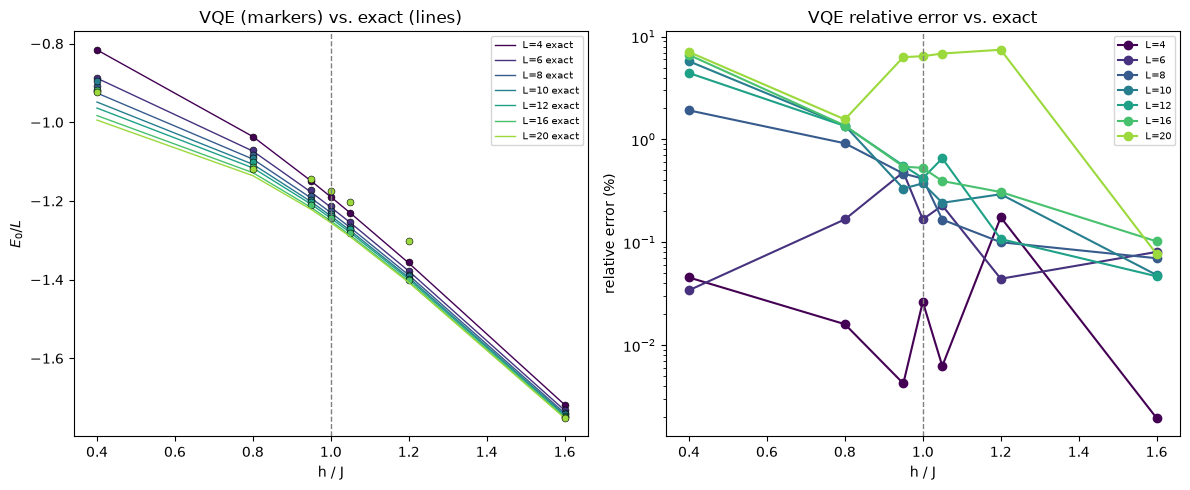

In [4]:
L_values = sorted({r["L"] for r in records})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0, 0.85, len(L_values)))
for L, color in zip(L_values, colors):
    pts = sorted((r["h"], r["E0"], r["E0_exact"]) for r in records if r["L"] == L)
    h_arr, e_vqe, e_exact = map(np.array, zip(*pts))
    ax1.plot(h_arr, e_exact / L, "-", color=color, linewidth=1, label=f"L={L} exact")
    ax1.plot(h_arr, e_vqe / L, "o", color=color, markersize=5, markeredgecolor="black", markeredgewidth=0.4)

    rel_err = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == L)
    h_e, err_e = map(np.array, zip(*rel_err))
    ax2.plot(h_e, err_e * 100, "o-", color=color, label=f"L={L}")

ax1.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("h / J")
ax1.set_ylabel("$E_0 / L$")
ax1.set_title("VQE (markers) vs. exact (lines)")
ax1.legend(fontsize=7)

ax2.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.set_yscale("log")
ax2.set_xlabel("h / J")
ax2.set_ylabel("relative error (%)")
ax2.set_title("VQE relative error vs. exact")
ax2.legend(fontsize=7)

fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "vqe_vs_exact.png", dpi=150)
plt.show()

## The L=20 problem

At `L ≤ 16`, 10 layers stays under 0.7% error everywhere. At `L=20` it doesn't — error jumps to 6-7% at every `h` except the deep-paramagnetic `h=1.6` and `h=0.8`:

In [5]:
l20 = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == 20)
for h, err in l20:
    print(f"h={h:<5} rel_err={err:.4%}")

h=0.4   rel_err=7.0793%
h=0.8   rel_err=1.5667%
h=0.95  rel_err=6.3148%
h=1.0   rel_err=6.4453%
h=1.05  rel_err=6.8401%
h=1.2   rel_err=7.4459%
h=1.6   rel_err=0.0769%


Two different mechanisms, not one:

- **Near h_c (h=0.95-1.2):** the HVA's nearest-neighbor gates spread correlations only ~1 site per layer, so a fixed 10-layer circuit can't span the diverging correlation length once the chain (`L=20`) outgrows the circuit's reach.
- **h=0.4 (deep ferromagnetic):** the true ground state there is GHZ-like — a genuine ansatz-*expressiveness* limit, not a correlation-length one (`configs/vqe_phase1_validation.yaml`'s comment notes 4 layers already showing 10.9% error at this `h`, well before criticality is even relevant).

Both are "not enough depth," but for different underlying reasons — worth checking whether the fix (more layers) works the same way for both.

## Does more depth fix it?

Reran `L=20` at `h=1.0` (critical point) and `h=0.4` (ferromagnetic) with more layers. This runs on `lightning.qubit` with adjoint differentiation rather than `default.qubit`'s default backprop — backprop's memory scales with circuit depth and runs out of room at these sizes, while adjoint differentiation keeps memory flat regardless of depth.

h=1.0  layers=10  rel_err=6.45%
h=1.0  layers=16  rel_err=0.58%
h=1.0  layers=24  rel_err=0.67%
h=0.4  layers=10  rel_err=7.08%
h=0.4  layers=16  rel_err=4.04%


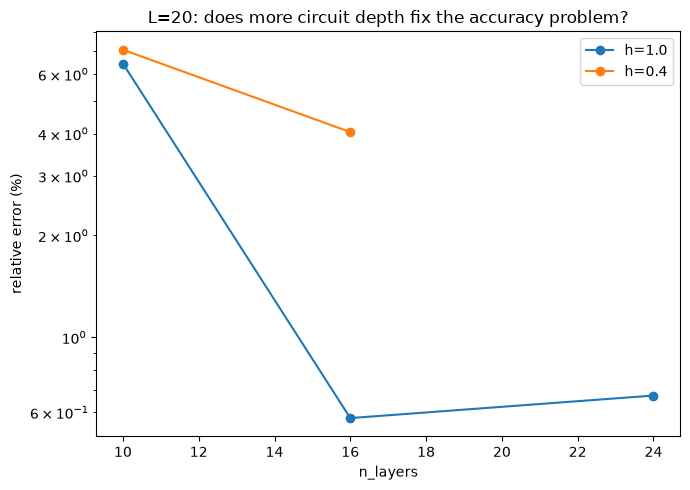

In [6]:
vqe_gpu_dir = REPO_ROOT / "results" / "vqe_gpu"


def depth_scan_point(h, n_layers):
    """10-layer points come from the original sim sweep; deeper ones from the L=20 rerun."""
    if n_layers == 10:
        path = results_dir / "20" / f"{h:.3f}.json"
    else:
        path = vqe_gpu_dir / "20" / f"{h:.3f}_layers{n_layers}.json"
    return json.loads(path.read_text())


depth_scans = {1.0: [10, 16, 24], 0.4: [10, 16]}

fig, ax = plt.subplots(figsize=(7, 5))
for h, layer_counts in depth_scans.items():
    pts = [(n, depth_scan_point(h, n)["rel_error"] * 100) for n in layer_counts]
    n_arr, err_arr = map(np.array, zip(*pts))
    ax.plot(n_arr, err_arr, "o-", label=f"h={h}")
    for n, err in pts:
        print(f"h={h:<4} layers={n:<3} rel_err={err:.2f}%")

ax.set_yscale("log")
ax.set_xlabel("n_layers")
ax.set_ylabel("relative error (%)")
ax.set_title("L=20: does more circuit depth fix the accuracy problem?")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "vqe_L20_depth_scan.png", dpi=150)
plt.show()

Depth helps, but not the same way for both mechanisms:

- **h=1.0:** error drops sharply from 10 to 16 layers (6.4% → 0.6%), then plateaus — 24 layers gives 0.7%, no further improvement within the same fixed training budget. Consistent with a pure circuit-reach limit: once the HVA's light cone spans the chain, adding more of the same layer type stops buying much.
- **h=0.4:** error also drops (7.1% → 4.0% at 16 layers) but far more modestly, and stays well above the h=1.0 result at the same depth. Consistent with the GHZ-expressiveness explanation above — a translationally-symmetric HVA layer (the same 2 parameters shared across the whole chain) doesn't resolve that limit just by adding more of the same layer.

**Depth strongly resolves the near-critical L=20 degradation, but only partially mitigates the ferromagnetic-regime one** — a real, physically-motivated difference between the two failure modes, not a uniform fix.